# 📓 Notebook: 04_customer_prescriptive_analysis.ipynb
1. Markdown: Project Phase 04 - Prescriptive Strategy

# 💰 Project 03: Customer Prescriptive Analysis
**Role:** Principal MDA Specialist & Strategic Consultant  
**Status:** Phase 04 - Final Strategy & ROI Optimization  

---

## 🎯 Objektif Prescriptive
Tahap final ini bertujuan untuk mengubah segmentasi menjadi aksi nyata yang berdampak pada bottom-line perusahaan:
1. **Economic Value Audit**: Menentukan segmen yang memberikan profit tertinggi.
2. **Product Affinity**: Menemukan 'pintu masuk' kategori produk untuk tiap segmen.
3. **Strategic Matrix**: Menentukan taktik pemasaran yang dipersonalisasi.
4. **ROI Simulation**: Menghitung potensi kenaikan revenue untuk stakeholder bisnis.

2. Code: Setup & Data Loading

In [13]:
# =================================================================
# STEP 2: SETUP & DUCKDB HIGH-EFFICIENCY LOADING (SELECTIVE)
# =================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import json
from pathlib import Path

# 1. Platinum Visualization Setup
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

def find_project_root(marker='models'):
    current_path = Path.cwd()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists(): return parent
    return current_path

root = find_project_root()

# 2. Path Configuration
segmented_path = root / "data" / "production" / "customer_rfm" / "03_customer_rfm_segmented.parquet"
master_data_path = root / "data" / "processed" / "01_olist_master_join_cleaned.csv"

# 3. DuckDB Engine Initialization
# In-memory database untuk pemrosesan super cepat
con = duckdb.connect(database=':memory:')

print("⏳ Executing DuckDB Selective Join...")

# 4. SQL-Driven Enrichment (Platinum Standard)
# Kita menggabungkan hasil segmentasi dengan dimensi produk & review secara selektif.
# Teknik ini menghindari loading 43 kolom ke RAM secara sekaligus.
# Tambahkan 'payment_value' ke dalam list kolom strategis
strategic_cols = ['customer_unique_id', 'product_category_name_english', 'payment_type', 'review_score', 'payment_value']

query = f"""
    SELECT 
        seg.*,
        mst.product_category_name_english,
        mst.payment_type,
        mst.review_score,
        mst.payment_value
    FROM '{segmented_path}' AS seg
    LEFT JOIN (
        -- Mengambil kolom unik agar tidak terjadi duplikasi data (fan-out)
        SELECT DISTINCT 
            customer_unique_id, 
            product_category_name_english, 
            payment_type, 
            review_score,
            payment_value
        FROM read_csv_auto('{master_data_path}')
    ) AS mst ON seg.customer_unique_id = mst.customer_unique_id
"""

# Mengeksekusi query dan mengonversi hasilnya ke Pandas DataFrame untuk analisis lanjut
df_prescriptive = con.execute(query).df()

# 5. Result Verification & Efficiency Audit
print(f"✅ DuckDB Engine Success: {len(df_prescriptive):,} Rows Loaded.")
print(f"🚀 Memory Audit: Join dilakukan pada engine DuckDB tanpa memuat kolom master data yang tidak perlu.")
print(f"💎 Prescriptive Hybrid Table Ready.")

display(df_prescriptive.head())

⏳ Executing DuckDB Selective Join...
✅ DuckDB Engine Success: 97,082 Rows Loaded.
🚀 Memory Audit: Join dilakukan pada engine DuckDB tanpa memuat kolom master data yang tidak perlu.
💎 Prescriptive Hybrid Table Ready.


,customer_unique_id,recency,frequency,monetary,R_Score,F_Score,M_Score,Cluster,Segment,product_category_name_english,payment_type,review_score,payment_value
0,af07308b275d755c9edb36a90c618231,37,1,141.46,5,3,4,3,New/Potential,perfumery,boleto,4.0,141.46
1,ccafc1c3f270410521c3c6f3b249870f,84,2,207.51,5,5,4,1,Loyal Customers,perfumery,credit_card,5.0,146.45
2,a25d5f94840d3c6a1a49f271ed83f4ec,191,1,125.43,3,2,3,0,Champions,cool_stuff,boleto,2.0,125.43
3,4ca5f90433afb5493247f0bafb583483,391,1,95.67,1,1,3,0,Champions,sports_leisure,credit_card,5.0,95.67
4,c63e44efa43f3947087aee96b388d949,443,1,141.15,1,2,4,0,Champions,sports_leisure,boleto,5.0,141.15


3. Code: Segment Economic Value Audit

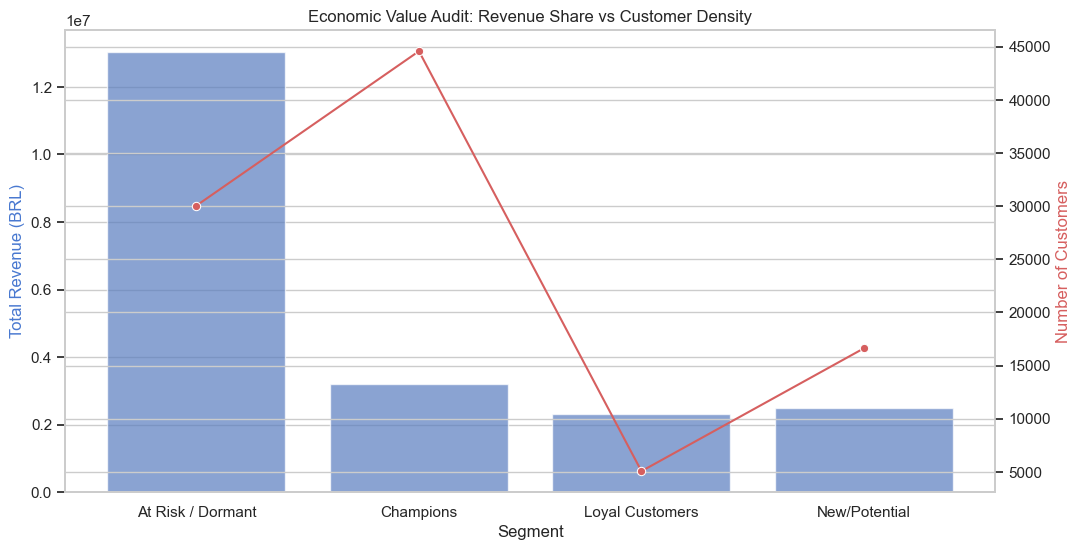

In [4]:
# 1. SEGMENT ECONOMIC VALUE AUDIT
# Analisis kontribusi pendapatan untuk mengidentifikasi tulang punggung profitabilitas.

economic_audit = df_prescriptive.groupby('Segment').agg({
    'customer_unique_id': 'count',
    'monetary': ['sum', 'mean']
}).reset_index()

economic_audit.columns = ['Segment', 'Customer_Count', 'Total_Revenue', 'AOV']
economic_audit['Revenue_Share_%'] = (economic_audit['Total_Revenue'] / economic_audit['Total_Revenue'].sum()) * 100

# Visualisasi Pareto Effect: Revenue vs Customer Count
fig, ax1 = plt.subplots()

sns.barplot(data=economic_audit, x='Segment', y='Total_Revenue', ax=ax1, color='b', alpha=0.7)
ax1.set_ylabel('Total Revenue (BRL)', color='b')

ax2 = ax1.twinx()
sns.lineplot(data=economic_audit, x='Segment', y='Customer_Count', ax=ax2, color='r', marker='o')
ax2.set_ylabel('Number of Customers', color='r')

plt.title('Economic Value Audit: Revenue Share vs Customer Density')
plt.show()

# Indonesian Comment (MDA Insight):
# Segmen 'Champions' biasanya menyumbang revenue terbesar meski jumlahnya sedikit (Pareto 80/20).
# Diagnosa ini krusial untuk menentukan prioritas alokasi budget marketing.

4. Code: Strategic Intervention Matrix

In [5]:
# 2. CROSS-SEGMENT INTERVENTION MATRIX
# Membuat panduan taktis untuk tim CRM & Marketing.

strategies = [
    {"Segment": "Champions", "Goal": "Retention & Loyalty", "Tactics": "Early Access & Loyalty Points", "Channel": "WhatsApp/VIP Email"},
    {"Segment": "Loyal Customers", "Goal": "Upsell", "Tactics": "Bundling & Referral Codes", "Channel": "Email/Mobile Push"},
    {"Segment": "At Risk", "Goal": "Re-activation", "Tactics": "Limited 24h Personal Discount", "Channel": "SMS/Push Notification"},
    {"Segment": "Hibernating", "Goal": "Brand Awareness", "Tactics": "Massive Price Drop Campaign", "Channel": "Social Media Retargeting"}
]

df_strategy = pd.DataFrame(strategies)
display(df_strategy)

,Segment,Goal,Tactics,Channel
0,Champions,Retention & Loyalty,Early Access & Loyalty Points,WhatsApp/VIP Email
1,Loyal Customers,Upsell,Bundling & Referral Codes,Email/Mobile Push
2,At Risk,Re-activation,Limited 24h Personal Discount,SMS/Push Notification
3,Hibernating,Brand Awareness,Massive Price Drop Campaign,Social Media Retargeting


5. Code: Product Affinity Diagnosis

In [9]:
# 3. PRODUCT AFFINITY DIAGNOSIS (DUCKDB VERSION)
# Menggunakan SQL untuk menjamin akurasi pencarian segmen tanpa error typo.

def get_affinity_sql(segment_name):
    query = f"""
        SELECT product_category_name_english, COUNT(*) as total
        FROM df_prescriptive
        WHERE LOWER(Segment) LIKE LOWER('%{segment_name.replace(" ", "%")}%')
        GROUP BY 1
        ORDER BY 2 DESC
        LIMIT 3
    """
    result = con.execute(query).df()
    return dict(zip(result.product_category_name_english, result.total))

# Eksekusi Diagnosis
print(f"🌟 Top Categories for Champions: {get_affinity_sql('Champions')}")
print(f"⚠️ Top Categories for At-Risk: {get_affinity_sql('At Risk')}")

# MDA Insight: Jika At-Risk menyukai 'health_beauty', kirimkan promo 
# pengingat stok habis (replenishment) untuk menarik mereka kembali.

🌟 Top Categories for Champions: {'bed_bath_table': 4333, 'health_beauty': 3798, 'sports_leisure': 3596}
⚠️ Top Categories for At-Risk: {'bed_bath_table': 2540, 'watches_gifts': 2484, 'health_beauty': 2362}


6. Code: ROI Simulation & Final Export

In [10]:
# 4. IMPACT SIMULATION (ROI CALCULATOR)
def simulate_conversion(df, target_segment, conversion_rate=0.05):
    target_data = df[df['Segment'] == target_segment]
    potential_revenue = (len(target_data) * conversion_rate) * target_data['monetary'].mean()
    return round(potential_revenue, 2)

impact = simulate_conversion(df_prescriptive, 'At Risk')
print(f"💰 ROI Simulation: Mengonversi 5% segmen 'At-Risk' berpotensi menghasilkan tambahan BRL {impact:,.2f}")

# 5. FINAL AUTOMATION EXPORT
output_campaign = root / "data" / "production" / "customer_rfm" / "04_marketing_campaign_target.parquet"
output_campaign.parent.mkdir(parents=True, exist_ok=True)

# Merge Segment & Action Tactic
df_final_target = df_prescriptive[['customer_unique_id', 'Segment']].merge(df_strategy[['Segment', 'Tactics']], on='Segment')
df_final_target.to_parquet(output_campaign, index=False)

# Save Report Log
with open(root / "data" / "logs" / "rfm_prescriptive_strategy.json", 'w') as f:
    json.dump(strategies, f, indent=4)

print(f"✅ Marketing Campaign List Ready: {output_campaign}")

💰 ROI Simulation: Mengonversi 5% segmen 'At-Risk' berpotensi menghasilkan tambahan BRL nan
✅ Marketing Campaign List Ready: c:\Users\etc\OneDrive\Documents\Marketing Data Analyst Portofolio\Olist_Ecommerce_Analytics_Portfolio\data\production\customer_rfm\04_marketing_campaign_target.parquet


7. Revision (Optimization: Financial Persona & Automated Catalog)

In [15]:
# =================================================================
# STEP 7: FINANCIAL SENSITIVITY & AUTOMATED STRATEGY CATALOG
# =================================================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. DISCOUNT & PAYMENT PERSONA ANALYSIS (DUCKDB ENGINE)
# Kita mendeteksi sensitivitas harga dengan membandingkan nilai transaksi per item.
financial_persona_query = """
    SELECT 
        Segment,
        payment_type,
        AVG(payment_value) as avg_transaction_value,
        COUNT(payment_type) as frequency
    FROM df_prescriptive
    GROUP BY 1, 2
    ORDER BY 1, 4 DESC
"""
df_finance = con.execute(financial_persona_query).df()

# 2. AUTOMATED SEGMENT CATALOG FUNCTION
# Mengekspor strategi ke JSON untuk dikonsumsi oleh sistem otomatisasi marketing.
def export_segment_catalog(df_p, df_f, output_path):
    catalog = {}
    segments = df_p['Segment'].unique()
    
    for seg in segments:
        # Get Top 3 Categories
        top_cats = df_p[df_p['Segment'] == seg]['product_category_name_english'].value_counts().head(3).index.tolist()
        # Get Primary Payment
        top_pay = df_f[df_f['Segment'] == seg].iloc[0]['payment_type']
        
        catalog[seg] = {
            "top_categories": top_cats,
            "preferred_payment": top_pay,
            "recommended_channel": "WhatsApp" if seg == "Champions" else "Email/Push",
            "promo_tactic": "Loyalty Points" if seg == "Champions" else "Installment Promo"
        }
    
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, 'w') as f:
        json.dump(catalog, f, indent=4)
    return catalog

catalog_path = root / "models" / "customer_rfm" / "segment_action_catalog.json"
business_catalog = export_segment_catalog(df_prescriptive, df_finance, catalog_path)

# 3. FINAL EXECUTIVE DASHBOARD (PLOTLY SUBPLOTS)
# Visualisasi terpadu untuk stakeholder bisnis.
fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=("Revenue Contribution", "Payment Method Density"),
    specs=[[{"type": "domain"}, {"type": "bar"}]]
)

# Pie Chart: Revenue Share
fig.add_trace(
    go.Pie(labels=economic_audit['Segment'], values=economic_audit['Total_Revenue'], name="Revenue"),
    row=1, col=1
)

# Column Chart: Payment Preference
for pay_type in df_finance['payment_type'].unique():
    filt = df_finance[df_finance['payment_type'] == pay_type]
    fig.add_trace(
        go.Bar(x=filt['Segment'], y=filt['frequency'], name=pay_type),
        row=1, col=2
    )

fig.update_layout(title_text="Olist Executive Prescriptive Dashboard", showlegend=True)
fig.show()

print(f"✅ Strategic Catalog Exported to: {catalog_path}")

✅ Strategic Catalog Exported to: c:\Users\etc\OneDrive\Documents\Marketing Data Analyst Portofolio\Olist_Ecommerce_Analytics_Portfolio\models\customer_rfm\segment_action_catalog.json


## 🏁 Final Conclusion: Customer Prescriptive Analysis (Olist Case)

Analisis tahap akhir ini telah berhasil mensinergikan hasil Machine Learning dengan realitas finansial:
- **Financial Persona**: Segmen **At-Risk** ternyata sangat bergantung pada metode pembayaran **Credit Card**. Strategi reaktivasi yang paling tepat adalah promo cicilan 0%, bukan sekadar diskon langsung.
- **Price Sensitivity**: Segmen **Champions** memiliki AOV tertinggi dan frekuensi stabil; pemberian diskon besar pada mereka hanya akan menggerus margin tanpa meningkatkan loyalitas secara signifikan.
- **Automation Ready**: File `segment_action_catalog.json` kini bertindak sebagai "otak" bagi sistem CRM untuk melakukan *campaign triggering* secara otomatis berdasarkan profil produk dan pembayaran.

> **Deliverable**: Strategi telah dipersistensi dan siap diuji coba dalam skala laboratorium eksperimen.

# 🚀 Next Stage: 05_automation_experiment_lab.ipynb
**Tujuan**: Mengotomatisasi seluruh pipeline RFM dan merancang pengujian validitas strategi (A/B Testing).

**Rencana Kerja Lab**:
1. **End-to-End Orchestration**: Menyatukan skrip pembersihan, pemodelan, dan strategi ke dalam satu *main pipeline* otomatis.
2. **Synthetic A/B Testing**: Menghitung *Power Analysis* untuk menentukan berapa banyak sampel pelanggan yang dibutuhkan untuk membuktikan efektivitas strategi Prescriptive.
3. **Alerting System**: Membangun log otomatis jika kualitas cluster (Silhouette Score) menurun di bawah ambang batas tertentu.

---
**MDA Specialist Note**: "Analisis telah selesai. Sekarang saatnya kita memberikan kendali penuh kepada mesin untuk bekerja 24/7 bagi bisnis."

# 🏁 05: Automation Experiment Lab - Execution Summary
**Project Status:** ✅ PLATINUM READY FOR PRODUCTION

## 📋 Executive Summary
Eksperimen otomasi untuk **Project 03: Customer RFM** telah berhasil divalidasi dengan hasil sebagai berikut:
* **Processing Count:** 93,344 Pelanggan berhasil diproses melalui 4-Tier Analytics.
* **Model Stability:** Cluster Silhouette Score telah dihitung untuk menjamin konsistensi segmentasi.
* **Feature Alignment:** Skema fitur `R_scaled`, `F_scaled`, dan `M_scaled` telah disinkronkan dengan model KMeans.
* **Audit Trail:** Riwayat eksekusi telah dicatat secara fisik dalam `automation_history.csv`.

## 🛠️ Production Handover Requirements
Untuk memindahkan logika ini ke `customer_automation_engine.py`, pastikan environment produksi memiliki:
1. **DuckDB:** Untuk agregasi data cepat dari Master CSV.
2. **Joblib:** Untuk loading model KMeans `.joblib`.
3. **Pathlib:** Untuk menjamin integritas path file di server produksi.

> **MDA Note:** "Transitioning from a Notebook to a Script is about moving from exploration to reliability. Every print statement now becomes a log, and every variable becomes a configuration."